In [2]:
# single-cell analysis package
library(Seurat)

# plotting and data science packages
library(purrr)
library(repr)
library(stringr)
library(dplyr) 
library(tidyverse)
library(ggplot2)
library(cowplot)
library(patchwork)

# co-expression network analysis packages:
library(WGCNA)
library(hdWGCNA)

# enable parallel processing for network analysis (optional)
enableWGCNAThreads(nThreads = 8)

# using the cowplot theme for ggplot
theme_set(theme_cowplot())

# set random seed for reproducibility
set.seed(12345)

Allowing parallel execution with up to 8 working processes.


In [3]:
# Output Directory
outDir <- file.path("./results")

# load the unprocessed dataset
wgcna_obj <- readRDS(file.path('./results/ST_tumor_hdWGCNA_object.rds'))
print(wgcna_obj)
length(GetWGCNAGenes(wgcna_obj))

An object of class Seurat 
33538 features across 11472 samples within 1 assay 
Active assay: Spatial (33538 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne
 8 spatial fields of view present: P1 P2 P3 P4 P5 P6 P7 P8


[1] 11729

## Linear Mixed Model

In [12]:
library(lme4)
library(lmerTest)
library(pbkrtest)
library(tibble)

In [5]:
# Prefer unharmonized MEs for the primary mixed model.
MEs <- GetMEs(
  wgcna_obj,
  harmonized = FALSE,
  wgcna_name = "HGSOC"
)

modules <- setdiff(colnames(MEs), "grey")

meta <- wgcna_obj@meta.data[
  rownames(MEs),
  c("patient", "chemotherapy_response"),
  drop = FALSE
]

meta$chemotherapy_response <- factor(
  meta$chemotherapy_response,
  levels = c("good", "poor", "partial")
)

me_df <- cbind(
  meta,
  as.data.frame(MEs[, modules, drop = FALSE])
)

# Primary comparison: good vs poor only
me_dat <- me_df %>%
  filter(chemotherapy_response %in% c("good", "poor")) %>%
  droplevels()

table(me_dat$patient, me_dat$chemotherapy_response)

    
     good poor
  P1    0 2465
  P2  917    0
  P3  665    0
  P5  153    0
  P7    0 3424
  P8    0 1105

In [6]:
mixed_results <- map_dfr(modules, function(mod) {

  dat <- me_dat %>%
    select(patient, chemotherapy_response, all_of(mod)) %>%
    dplyr::rename(ME = all_of(mod)) %>%
    na.omit()

  # Make good responders the reference group
  dat$chemotherapy_response <- relevel(
    dat$chemotherapy_response,
    ref = "good"
  )

  # Linear mixed-effects model
  fit <- lmer(
    ME ~ chemotherapy_response + (1 | patient),
    data = dat,
    REML = TRUE
  )

  # Satterthwaite inference
  coef_tab <- summary(fit)$coefficients

  # Extract poor vs good effect
  beta <- coef_tab["chemotherapy_responsepoor", "Estimate"]
  se <- coef_tab["chemotherapy_responsepoor", "Std. Error"]
  pval <- coef_tab["chemotherapy_responsepoor", "Pr(>|t|)"]

  # 95% CI
  ci <- confint(
    fit,
    parm = "chemotherapy_responsepoor",
    method = "Wald"
  )

  tibble(
    module = mod,
    beta = beta,
    SE = se,
    CI_low = ci[1],
    CI_high = ci[2],
    p_value = pval
  )
})

#write.csv(mixed_results, "mixedmodelresults.csv", row.names = FALSE)
mixed_results

module,beta,SE,CI_low,CI_high,p_value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Tumor-M6,6.7076374,3.012017,0.8041924,12.611082465,0.08982175
Tumor-M7,0.2695681,3.930084,-7.4332552,7.972391528,0.94860423
Tumor-M2,2.7912773,8.454508,-13.7792535,19.361808210,0.75783428
Tumor-M1,-17.3020063,4.718660,-26.5504091,-8.053603513,0.02144077
Tumor-M3,0.7865299,2.432703,-3.9814813,5.554541095,0.76262887
Tumor-M4,0.9559092,5.392320,-9.6128443,11.524662750,0.86790043
Tumor-M5,-3.7180064,1.900095,-7.4421237,0.006110843,0.12175538


## Pseudo-Bulk Approach

In [7]:
patient_ME <- me_dat |>
    dplyr::group_by(patient, chemotherapy_response) |>
    dplyr::summarise(
        dplyr::across(
            dplyr::all_of(modules),
            ~ mean(.x, na.rm = TRUE)
        ),
        .groups = "drop"
    )
print(dim(patient_ME))
patient_ME

[1] 6 9


patient,chemotherapy_response,Tumor-M6,Tumor-M7,Tumor-M2,Tumor-M1,Tumor-M3,Tumor-M4,Tumor-M5
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P1,poor,-2.348940,-6.84303443,18.6512779,-2.5986377,-1.2037594,-3.708816,-4.73068665
P2,good,-9.665374,-1.73726822,-3.5834048,22.5986864,0.7538345,-3.585466,-1.50997819
P3,good,-1.260831,-0.77428101,0.2771945,6.8488480,1.4880800,5.626072,2.10690163
P5,good,-6.847426,-0.09165887,3.4431762,16.8729232,-0.2399223,-2.482092,1.85600231
P7,poor,3.583277,6.56901809,-8.8390427,-3.1718365,-0.6299717,-3.746153,-4.04422454
P8,poor,1.117890,-1.52231299,-1.3104104,0.1836836,6.2016541,9.892686,0.06052173


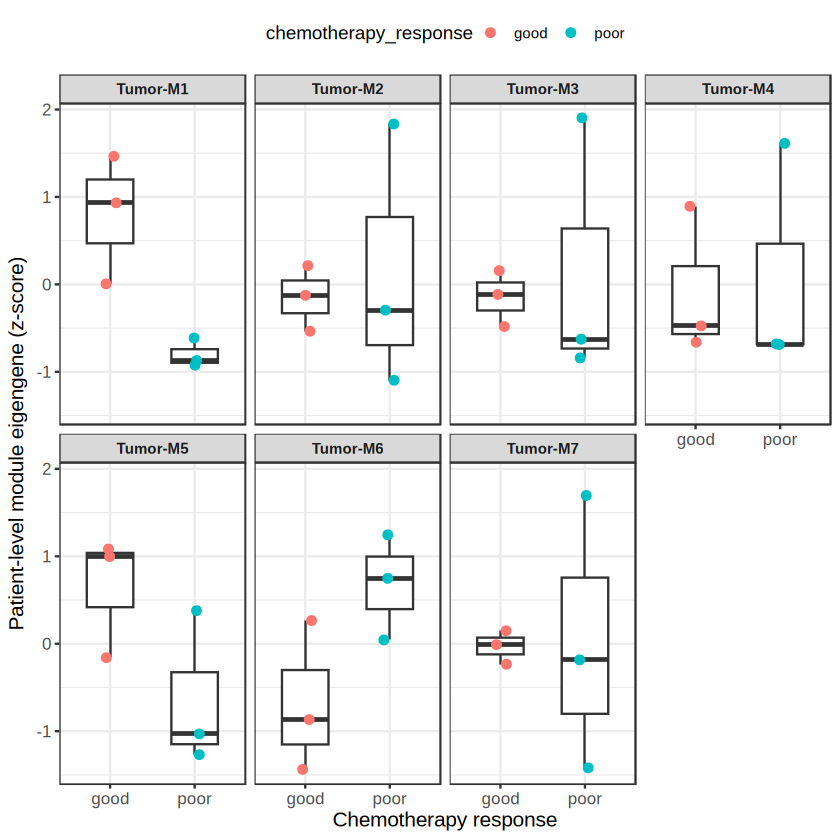

In [8]:
# Convert module columns to long format
patient_ME_long <- patient_ME %>%
  pivot_longer(
    cols = -c(patient, chemotherapy_response),
    names_to = "module",
    values_to = "ME"
  )

# Standardize ME within each module
patient_ME_long <- patient_ME_long %>%
  group_by(module) %>%
  mutate(
    ME_z = as.numeric(scale(ME))
  ) %>%
  ungroup()

# Set response order
patient_ME_long$chemotherapy_response <- factor(
  patient_ME_long$chemotherapy_response,
  levels = c("good", "poor")
)

# Plot
ggplot(
  patient_ME_long,
  aes(
    x = chemotherapy_response,
    y = ME_z
  )
) +
  geom_boxplot(
    width = 0.55,
    outlier.shape = NA
  ) +
  geom_jitter(
    aes(color = chemotherapy_response),
    width = 0.08,
    size = 2
  ) +
  facet_wrap(
    ~ module,
    ncol = 4
  ) +
  labs(
    x = "Chemotherapy response",
    y = "Patient-level module eigengene (z-score)"
  ) +
    theme_bw() +
  theme(
    strip.text = element_text(face = "bold"),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
          legend.position = "top"

  )

In [9]:
# #options(repr.plot.height = 10, repr.plot.width = 10)

# png(filename = "./module_pseudobulk_boxplot.png", width = 2400, height = 1800, res = 300)
# # Plot
# ggplot(
#   patient_ME_long,
#   aes(
#     x = chemotherapy_response,
#     y = ME_z
#   )
# ) +
#   geom_boxplot(
#     width = 0.55,
#     outlier.shape = NA
#   ) +
#   geom_jitter(
#     aes(color = chemotherapy_response),
#     width = 0.08,
#     size = 2
#   ) +
#   facet_wrap(
#     ~ module,
#     ncol = 4
#   ) +
#   labs(
#     x = "Chemotherapy response",
#     y = "Patient-level module eigengene (z-score)"
#   ) +
#     theme_bw() +
#   theme(
#     strip.text = element_text(face = "bold"),
#     axis.title = element_text(size = 12),
#     axis.text = element_text(size = 10),
#     legend.position = "top"

#   )
# dev.off()